# 03 - Backtest Baseline Inspection

This notebook inspects outputs from the baseline backtest. It reads generated CSV files and performs sanity checks on weights, active weights, turnover, and benchmark comparison tables.

## Portfolio Structure

The intended index-enhancement structure is:

$$ w_{i,t} = b_{i,t} + a_{i,t}$$

where `b_i,t` is the benchmark proxy weight, `a_i,t` is the active factor tilt, and `w_i,t` is the final long-only portfolio weight.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"

def read_series_csv(path, parse_dates=True):
    frame = pd.read_csv(path, index_col=0, parse_dates=parse_dates)
    return frame.iloc[:, 0]

def read_required_csv(path, **kwargs):
    if not path.exists():
        raise FileNotFoundError(f"Run python main.py first. Missing: {path}")
    return pd.read_csv(path, **kwargs)

## Load Backtest Outputs

In [2]:
portfolio_returns = read_series_csv(DATA_PROCESSED / "portfolio_returns_net.csv")
benchmark_returns = read_series_csv(DATA_PROCESSED / "benchmark_returns.csv")
turnover = read_series_csv(DATA_PROCESSED / "turnover.csv")
weights = read_required_csv(DATA_PROCESSED / "weights.csv", index_col=0, parse_dates=True)

print(f"Portfolio return observations: {len(portfolio_returns)}")
print(f"Weight snapshots: {len(weights)}")
display(weights.tail())
display(turnover.tail())

Portfolio return observations: 2604
Weight snapshots: 125


,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,APP,COIN,HOOD,CEG,GEHC,KVUE,VLTO,GEV,SOLV,SNDK
2026-02-02,0.000297,0.056096,0.005609,0.002346,0.000601,0.000884,0.001244,0.002864,0.000465,0.001112,...,0.003355,0.000000,0.001960,0.002009,0.000306,0.000000,0.000425,0.004461,0.000310,NaN
2026-03-02,0.000518,0.055807,0.005082,0.001532,0.000478,0.001266,0.000835,0.002925,0.001067,0.001099,...,0.002424,0.000218,0.001906,0.001026,0.000000,0.000000,0.000318,0.004423,0.000000,0.004852
2026-04-01,0.000222,0.056116,0.005142,0.001839,0.000451,0.000560,0.000540,0.003335,0.000762,0.000513,...,0.001898,0.000000,0.001124,0.001889,0.000237,0.000000,0.000247,0.004950,0.000000,0.004742
2026-05-01,0.000491,0.056186,0.005281,0.001918,0.000608,0.000862,0.000600,0.002974,0.001084,0.000543,...,0.001680,0.000000,0.000650,0.001367,0.000503,0.000025,0.000245,0.004494,0.000005,0.004845
2026-06-01,0.000062,0.055960,0.005128,0.001705,0.000539,0.000583,0.000514,0.003219,0.000938,0.000589,...,0.001212,0.000000,0.000130,0.001246,0.000000,0.000149,0.000258,0.004702,0.000000,0.005148


2026-02-02    0.045519
2026-03-02    0.059442
2026-04-01    0.058429
2026-05-01    0.048422
2026-06-01    0.040908
Name: value, dtype: float64

## Weight Sanity Checks

In [3]:
weight_sums = weights.sum(axis=1)
min_weights = weights.min(axis=1)

checks = pd.DataFrame(
    {
        "weight_sum": weight_sums,
        "min_weight": min_weights,
        "max_weight": weights.max(axis=1),
        "nonzero_holdings": (weights > 0).sum(axis=1),
    }
)
display(checks.tail(10))

print(f"Latest weight sum: {weight_sums.iloc[-1]:.12f}")
print(f"Latest min weight: {min_weights.iloc[-1]:.12f}")
print(f"All latest weights non-negative: {(weights.iloc[-1] >= -1e-12).all()}")

,weight_sum,min_weight,max_weight,nonzero_holdings
2025-09-02,1.0,0.0,0.066680,405
2025-10-01,1.0,0.0,0.066583,413
2025-11-03,1.0,0.0,0.066628,409
2025-12-01,1.0,0.0,0.067207,399
2026-01-02,1.0,0.0,0.066571,409
2026-02-02,1.0,0.0,0.066682,416
2026-03-02,1.0,0.0,0.066693,413
2026-04-01,1.0,0.0,0.066796,411
2026-05-01,1.0,0.0,0.066714,421
2026-06-01,1.0,0.0,0.066532,412


Latest weight sum: 1.000000000000
Latest min weight: 0.000000000000
All latest weights non-negative: True


## Active Weights versus Static Market-Cap Proxy

If static market-cap weights are available, compare the latest portfolio weights to that proxy benchmark.

In [4]:
static_weights_path = DATA_PROCESSED / "static_market_cap_weights.csv"

if static_weights_path.exists():
    static_weights = pd.read_csv(static_weights_path, index_col=0).iloc[:, 0]
    latest_weights = weights.iloc[-1]
    aligned_index = latest_weights.index.union(static_weights.index)
    active_weights = latest_weights.reindex(aligned_index, fill_value=0.0) - static_weights.reindex(aligned_index, fill_value=0.0)
    active_weights = active_weights.sort_values(ascending=False)

    print(f"Active weight sum: {active_weights.sum():.12f}")
    print(f"Max absolute active weight: {active_weights.abs().max():.6f}")
    print("Top overweights")
    display(active_weights.head(15).to_frame("active_weight"))
    print("Top underweights")
    display(active_weights.tail(15).to_frame("active_weight"))
else:
    print(f"No static market-cap weights found at {static_weights_path}")

Active weight sum: 0.000000000000
Max absolute active weight: 0.002497
Top overweights


,active_weight
SNDK,0.002497
LITE,0.002065
SATS,0.001688
WDC,0.001573
CIEN,0.001268
WBD,0.001234
ALB,0.001149
FIX,0.001139
STX,0.001085
APA,0.000942


Top underweights


,active_weight
QCOM,-0.000947
ADBE,-0.000950
ACN,-0.000997
CRWD,-0.001018
INTU,-0.001051
ORCL,-0.001054
APP,-0.001065
TSLA,-0.001121
NOW,-0.001352
AMZN,-0.001375


## Benchmark and Factor Variant Tables

In [5]:
benchmark_comparison = read_required_csv(REPORTS / "benchmark_comparison.csv")
factor_variants = read_required_csv(REPORTS / "factor_variant_sensitivity.csv")

display(benchmark_comparison)
display(factor_variants.sort_values("information_ratio", ascending=False))

,benchmark,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio
0,SPY,12.179864,0.283449,0.204965,1.320881,-0.333005,0.576421,0.108990,0.052837,2.062754
1,EqualWeightUniverse,12.179864,0.283449,0.204965,1.320881,-0.333005,0.576421,0.083018,0.087663,0.947020


,variant,factors,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio,average_turnover,annualized_turnover
1,lowvol_only,lowvol,10.845407,0.256415,0.197454,1.255540,-0.329902,0.572371,0.099305,0.045228,2.195641,0.018228,0.218732
5,lowvol_reversal,"lowvol,reversal",10.846844,0.256429,0.201002,1.236944,-0.338261,0.573470,0.100023,0.046990,2.128600,0.067270,0.807237
3,momentum_lowvol,"momentum,lowvol",12.331548,0.284871,0.204112,1.330985,-0.330334,0.576421,0.109925,0.052722,2.085003,0.034425,0.413101
0,momentum_only,momentum,13.289028,0.293524,0.208032,1.342089,-0.331145,0.577573,0.117456,0.056578,2.076002,0.037002,0.444026
6,combined,"momentum,lowvol,reversal",12.179864,0.283449,0.204965,1.320881,-0.333005,0.576421,0.108990,0.052837,2.062754,0.052803,0.633633
4,momentum_reversal,"momentum,reversal",13.169266,0.292471,0.209058,1.332622,-0.334577,0.577189,0.116852,0.056708,2.060599,0.058567,0.702800
2,reversal_only,reversal,12.645984,0.261403,0.208891,1.216893,-0.346613,0.566996,0.110206,0.055678,1.979335,0.120832,1.449983


## Version 1.1 Active Exposure Diagnostics

These diagnostics measure how far the realized portfolio weights move away from the benchmark proxy through time. They are especially useful in `market_cap_static` mode, where the benchmark proxy uses current market caps and therefore introduces look-ahead bias.

In [6]:
active_exposure = read_required_csv(REPORTS / "active_exposure_diagnostics.csv", index_col=0, parse_dates=True)
active_exposure_summary = read_required_csv(REPORTS / "active_exposure_summary.csv", index_col=0)

display(active_exposure_summary)

diagnostic_columns = [
    "gross_active_exposure",
    "active_share",
    "net_active_weight",
    "max_absolute_active_weight",
]
display(active_exposure.loc[:, diagnostic_columns].describe())

,value
average_gross_active_exposure,0.182210
average_active_share,0.091105
max_active_share,0.106110
average_max_absolute_active_weight,0.004410
max_absolute_active_weight,0.004992
average_abs_net_active_weight,0.000445


,gross_active_exposure,active_share,net_active_weight,max_absolute_active_weight
count,125.000000,125.000000,1.250000e+02,125.000000
mean,0.182210,0.091105,-4.451666e-04,0.004410
std,0.014784,0.007392,3.594219e-04,0.000787
min,0.153140,0.076570,-1.298363e-03,0.002193
25%,0.170268,0.085134,-7.113660e-04,0.004116
50%,0.180918,0.090459,-4.223190e-04,0.004992
75%,0.193273,0.096637,-1.013943e-04,0.004992
max,0.212219,0.106110,2.027458e-16,0.004992


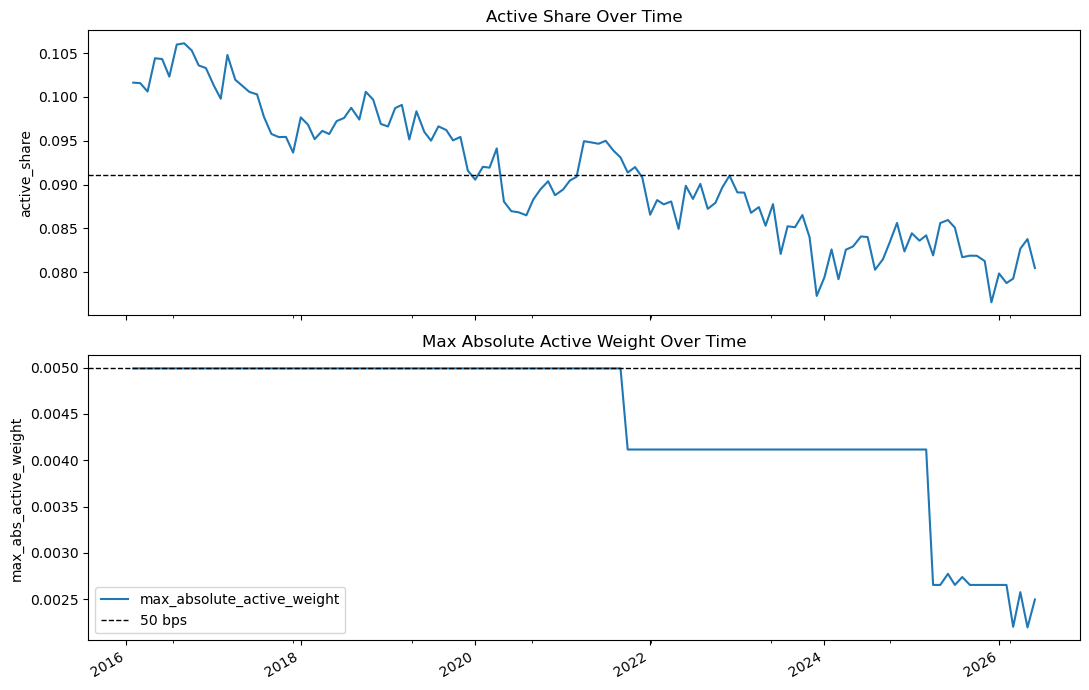

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
active_exposure["active_share"].plot(ax=axes[0], title="Active Share Over Time")
axes[0].set_ylabel("active_share")
axes[0].axhline(active_exposure["active_share"].mean(), color="black", linestyle="--", linewidth=1)

active_exposure["max_absolute_active_weight"].plot(ax=axes[1], title="Max Absolute Active Weight Over Time")
axes[1].set_ylabel("max_abs_active_weight")
axes[1].axhline(0.005, color="black", linestyle="--", linewidth=1, label="50 bps")
axes[1].legend()

plt.tight_layout()
plt.show()

The current active exposure summary shows average active share around 9.1%, while the maximum absolute active weight remains below 50 bps. This is consistent with an index-enhancement framework: the strategy takes small active tilts and stays close to the benchmark proxy. The benchmark proxy still uses current market caps in `market_cap_static` mode, so these diagnostics confirm portfolio closeness but do not remove look-ahead bias.

## Interpretation Warning

The static market-cap proxy is not point-in-time. It makes the portfolio construction conceptually closer to S&P 500 index enhancement, but applying current market caps historically introduces look-ahead bias. Strong results in this mode should be interpreted as framework demonstration, not tradable historical evidence.